:::{note}
Running this on Colab or a fresh environment? Install the family from PyPI,
following eagle's
[install guide](https://amasat01.github.io/eagle/content/userguide/installation.html).
The NVIDIA packages come only through the `[cuda12]` / `[cuda13]` extras:

```
# !pip install "raptor-hawk[cuda12]" "raptor-eagle[cuda12]" matplotlib
```
:::

# Thirty seconds: `eagle.simulate`

> Write one sample's step, hand it to `eagle.simulate`, and it runs every
> sample until it's done — on the CPU or the GPU, no loop of your own.

**Time:** < 1 min · **Runs on:** CPU (GPU: this notebook picks it up
automatically) · **You need:** nothing — the kernel is given below.

You will build the figure at the bottom of this page: where each oscillator
in the batch ends up, as a function of its own frequency.

## The code

Write the step as a [hawk](https://amasat01.github.io/hawk/) kernel: a
`Mutable` plane is what it updates, a `Param` is one number shared by every
sample, a `Scalar` one number per sample, and the line `terminated = ...`
says when a sample is done. `eagle.simulate` takes the kernel, then its
arguments exactly as you would call it -- an array gives each sample its
own value, a plain number is shared by every sample -- and runs every
sample until it finishes (or `max_steps` is reached).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import gpu_available, plot_style, to_numpy, xp_for
plot_style()

In [2]:
DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)
print("running on", DEVICE)

running on cpu


In [3]:
import eagle
import hawk
from hawk import Mutable, Param, Scalar, Terminated


@hawk.kernel
def oscillator(omega: Scalar, t_end: Param, dt: Param, terminated: Terminated,
               x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x0, v0 = x, v
    x = x0 + dt * v0
    v = v0 - dt * omega * omega * x0
    t += dt
    terminated = t >= t_end


n = 1_000_000 if DEVICE == "gpu" else 100_000  # CPU: a smaller batch, same call
omega = xp.linspace(1.0, 3.0, n)
result = eagle.simulate(
    oscillator,
    omega=omega, t_end=1.0, dt=1e-3,
    x=xp.ones(n), v=xp.zeros(n), t=xp.zeros(n),
    max_steps=10_000,
)
print(result.status, result.steps, "launches:", result.report.launches)

finished 1024 launches: 16


## What it printed

`"finished"` and the step count the batch took; every sample here shares the
same stop time (`t_end`), so they all take exactly the same number of steps.
`result.x` is the very array passed in, updated in place.

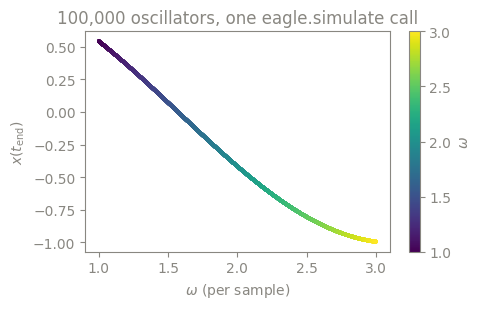

In [4]:
import matplotlib.pyplot as plt

omega_host, x_host = to_numpy(omega), to_numpy(result.x)

fig, ax = plt.subplots(figsize=(5, 3.2))
sc = ax.scatter(omega_host, x_host, s=3, c=omega_host, cmap="viridis")
ax.set_xlabel(r"$\omega$ (per sample)")
ax.set_ylabel(r"$x(t_\mathrm{end})$")
ax.set_title(f"{n:,} oscillators, one eagle.simulate call")
fig.colorbar(sc, ax=ax, label=r"$\omega$")
fig.tight_layout()
plt.show()

## What just happened

- `eagle.simulate` ran every sample's kernel until its own `terminated`
  fired, and wrote the final state back into the arrays you gave it.
- The data decided where it ran: numpy arrays run on the CPU through eagle's
  OpenMP team; cupy arrays run the *exact same call* on the GPU.
- `result.report` counts what the call did underneath (`launches`, `steps`)
  — one call, no loop you had to write.

## Try this

Change `dt` to `1e-4` and re-run: `result.steps` grows tenfold, the kernel
is unchanged.

## Next

- {doc}`tutorials/02_cuda_graphs_python` — see what one launch replaying
  many times buys you, and why that kills launch overhead.
- {doc}`tutorials/01_launch_and_registry` (how-to) — load a kernel *someone
  else* compiled instead of writing one, and call it directly.
- deeper: {doc}`../performance` — the full measurement behind "one call,
  no loop", on both a GPU and a CPU.